In [1]:
import duckdb
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import polars as pl
import seaborn as sns

from advan_test import data
from advan_test.utils import project_root

In [2]:
ROOT = project_root()
DATA_PATH = ROOT / "data"
DUCK_PATH = DATA_PATH / "mydb.duckdb"
PARQUET_DIR_PATH = DATA_PATH / "2025-weekly-patterns-plus"
DATA_GLOB = PARQUET_DIR_PATH / "*.parquet"
CSV_PATH = DATA_PATH / "weekly-patterns-plus-sample.csv"
US_PATH = DATA_PATH / "us-states.json"
SHP_PATH = DATA_PATH / "tl_2025_04_bg" / "tl_2025_04_bg.shp"

In [3]:
# config
sns.set_theme(style="ticks")
pl.Config.set_engine_affinity("streaming")

con = duckdb.connect(DUCK_PATH, read_only=False)
con.install_extension("spatial")
con.load_extension("spatial")

In [4]:
con.execute(f"""
    CREATE TABLE IF NOT EXISTS states AS
    SELECT * FROM ST_Read('{US_PATH}')
""")
con.execute(f"""
    CREATE TABLE IF NOT EXISTS arizona_shp AS
    SELECT * FROM '{SHP_PATH}'
""")
con.execute(f"""
    CREATE TABLE IF NOT EXISTS wpp_arizona AS
    WITH boundary AS (
        SELECT geom
        FROM states 
        WHERE name = 'Arizona'
    ), t AS (
        SELECT *
        FROM '{DATA_GLOB}'
    )
    SELECT t.*
    FROM t, boundary
    WHERE ST_Within(
        ST_Point(t.LONGITUDE, t.LATITUDE),
        boundary.geom
    )
""")

In [5]:
lf = con.sql("SELECT * FROM wpp_arizona").pl().lazy()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [6]:
lf.select(pl.col("ID_STORE").n_unique()).collect()

ID_STORE
u32
121168


In [7]:
pois = lf.group_by("BRAND", "LONGITUDE", "LATITUDE").agg(
    pl.col("VISITOR_COUNTS").sum().cast(pl.Float64),
    pl.col("VISITOR_COUNTS").sum().log().cast(pl.Float64).alias("LOG_VISITOR_COUNTS")
).with_columns(
    pl.col("VISITOR_COUNTS")
        .qcut(10, labels=[str(i) for i in range(1, 11)])
        .cast(pl.Utf8).cast(pl.Int64).alias("VISITOR_DECILE")
).collect()

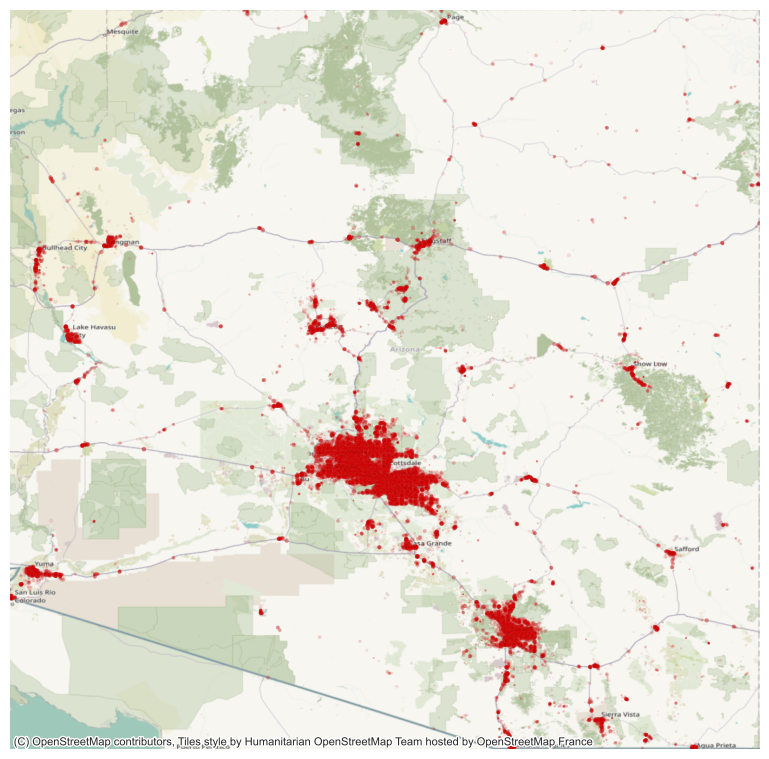

In [8]:
fig_scale = 2
fig, ax = plt.subplots(figsize=(6.4*fig_scale, 4.8*fig_scale))
ax = sns.scatterplot(
    pois, x="LONGITUDE", y="LATITUDE",
    color="#c00", size="VISITOR_DECILE", sizes=(1, 10),
    alpha=.1, ax=ax, legend=False
)
ax.set_xlim(pois["LONGITUDE"].min(), pois["LONGITUDE"].max())
ax.set_ylim(pois["LATITUDE"].min(), pois["LATITUDE"].max())
cx.add_basemap(ax, crs="EPSG:4326", zoom=8)
ax.set_axis_off()
ax.set_aspect("equal")

<Axes: >

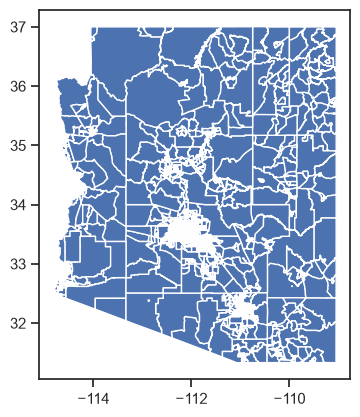

In [9]:
df = con.sql("SELECT * FROM arizona_shp").df()
df["geom"] = df["geom"].apply(bytes)
gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.GeoSeries.from_wkb(df["geom"]), 
    crs="EPSG:4326"
)
gdf.plot()

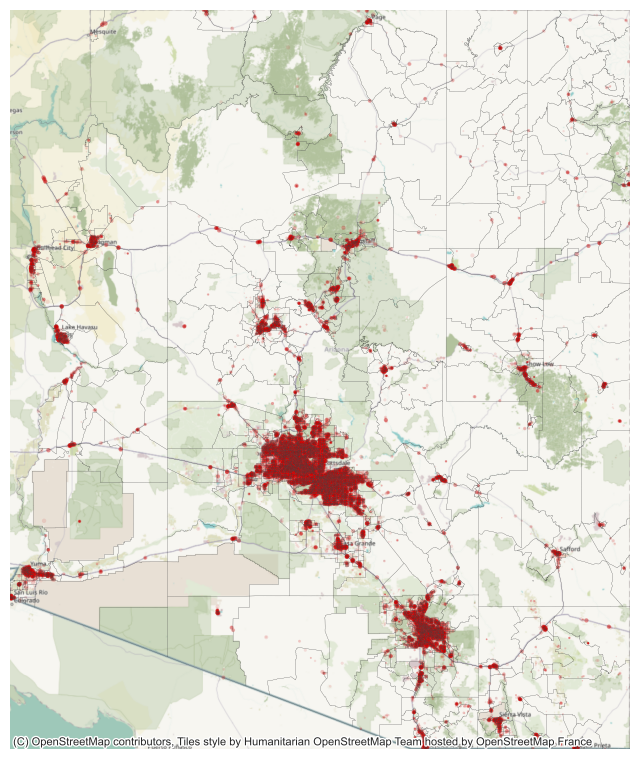

In [10]:
fig_scale = 2
fig, ax = plt.subplots(figsize=(6.4*fig_scale, 4.8*fig_scale))
gdf.boundary.plot(ax=ax, color="#444", linewidth=0.1)
ax = sns.scatterplot(
    pois, x="LONGITUDE", y="LATITUDE",
    color="#c00", size="VISITOR_DECILE", sizes=(1, 10),
    alpha=.1, ax=ax, legend=False
)
ax.set_xlim(pois["LONGITUDE"].min(), pois["LONGITUDE"].max())
ax.set_ylim(pois["LATITUDE"].min(), pois["LATITUDE"].max())
cx.add_basemap(ax, crs="EPSG:4326", zoom=8)
ax.set_axis_off()

In [11]:
poi_od = con.sql(f"""
    SELECT 
        ID_STORE,
        UNNEST(map_keys(M)) AS HOME_CBG,
        POI_CBG,
        UNNEST(map_values(M)) AS VISITOR_COUNT
    FROM (
        SELECT *, CAST(VISITOR_HOME_CBGS::JSON AS MAP(VARCHAR, INTEGER)) AS M
        FROM wpp_arizona
    )
""").pl().lazy()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [12]:
od = (
    poi_od
        .filter(pl.col("HOME_CBG").str.starts_with("04"))
        .group_by("HOME_CBG", "POI_CBG")
        .agg(pl.col("VISITOR_COUNT").sum())
        .collect()
)

In [13]:
cb = con.sql("SELECT GEOID, ST_X(ST_Centroid(geom)) AS CENT_LON, ST_Y(ST_Centroid(geom)) AS CENT_LAT FROM arizona_shp").pl()
cb.head()

GEOID,CENT_LON,CENT_LAT
str,f64,f64
"""040270010012""",-114.616014,32.660697
"""040270010013""",-114.633637,32.652245
"""040270111121""",-114.399578,32.645345
"""040138148023""",-111.716366,33.324667
"""040134226521""",-111.592311,33.367046


In [14]:
pos = dict(
    zip(
        cb["GEOID"],
        zip(cb["CENT_LON"], cb["CENT_LAT"])
    )
)
edges_df = od.filter(pl.col("HOME_CBG") != pl.col("POI_CBG")).top_k(10_000, by="VISITOR_COUNT")
edges = [
    (h, p, w) for h, p, w in edges_df.iter_rows()
    if h in pos and p in pos
]

G = nx.DiGraph()
G.add_weighted_edges_from(edges)
sub_pos = {n: pos[n] for n in G.nodes()}

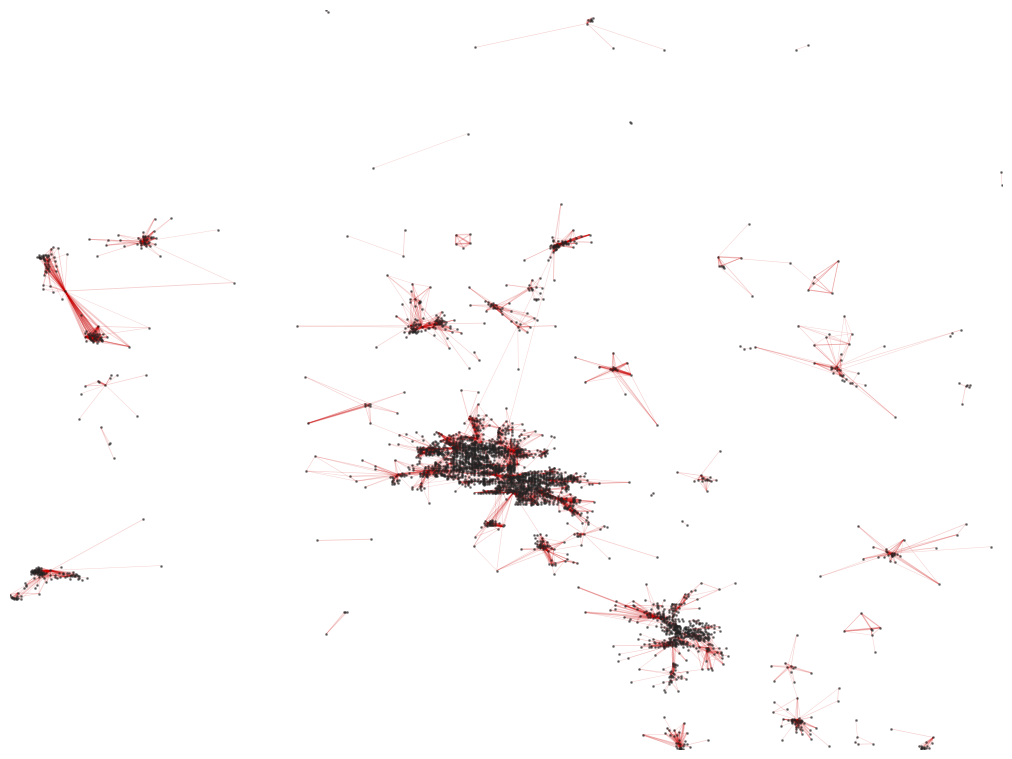

In [15]:
fig_scale = 2
fig, ax = plt.subplots(figsize=(6.4*fig_scale, 4.8*fig_scale))

# state boundary
# gdf.boundary.plot(ax=ax, color="#222", linewidth=0.1)

# draw the OD graph using real coordinates
weights = np.array([G[u][v]["weight"] for u, v in G.edges()])
edge_widths = 0.1 + 3 * (weights / weights.max())  # scale line width by flow

nx.draw_networkx_edges(
    G, pos=sub_pos, ax=ax,
    edge_color="#c00", alpha=0.2, width=edge_widths,
    arrows=False,  # cleaner for large OD plots
)
nx.draw_networkx_nodes(
    G, pos=sub_pos, ax=ax,
    node_size=1, node_color="#222", alpha=0.5,
)

# match extent to your data (or to gdf.total_bounds for the full state)
xs = [p[0] for p in sub_pos.values()]
ys = [p[1] for p in sub_pos.values()]
ax.set_xlim(min(xs), max(xs))
ax.set_ylim(min(ys), max(ys))

#cx.add_basemap(ax, crs="EPSG:4326", zoom=8)
ax.set_axis_off()

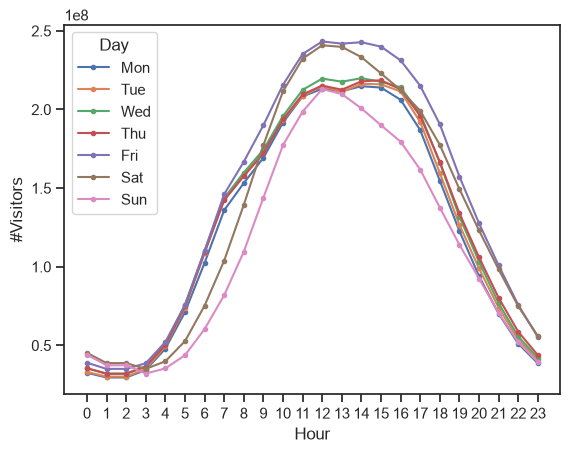

In [17]:
hour_sum = con.sql("""
    WITH x AS (
        SELECT from_json(VISITS_BY_EACH_HOUR, '["INTEGER"]')::INTEGER[168] AS VISITS_BY_EACH_HOUR
        FROM wpp_arizona
        WHERE VISITS_BY_EACH_HOUR IS NOT NULL
    ), y AS (
        SELECT
            unnest(VISITS_BY_EACH_HOUR) AS VISITS,
            generate_subscripts(VISITS_BY_EACH_HOUR, 1) AS HOUR
        FROM x
    )
    SELECT 
        HOUR, SUM(VISITS) AS VISITS
    FROM y
    GROUP BY 1
    ORDER BY 1
""").pl().select("VISITS").to_numpy().T[0]

n = hour_sum.shape[0]
hours_per_day = 24
n_days = n // hours_per_day  # 7

x = np.arange(hours_per_day)
_, ax = plt.subplots()

day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

for i in range(n_days):
    start = i * hours_per_day
    end = start + hours_per_day
    day_data = hour_sum[start:end]
    label = day_names[i] if i < len(day_names) else f"Day {i + 1}"
    ax.plot(x, day_data, label=label, marker="o", markersize=3)

ax.set_xticks(x)
ax.set_xlabel("Hour")
ax.set_ylabel("#Visitors")
ax.legend(title="Day")

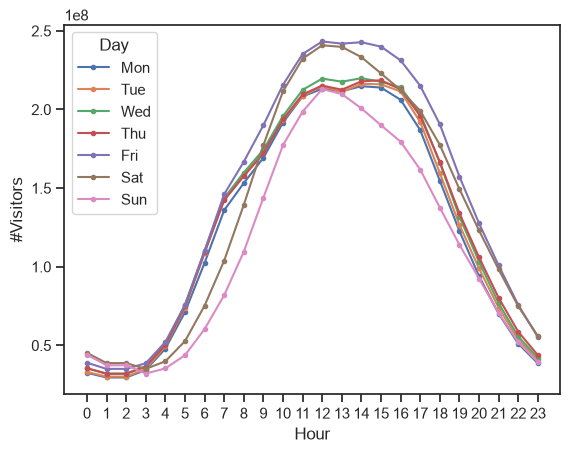

In [18]:
hour_sum = con.sql("""
    SELECT from_json(VISITS_BY_EACH_HOUR, '["INTEGER"]') AS VISITS_BY_EACH_HOUR
    FROM wpp_arizona
    WHERE VISITS_BY_EACH_HOUR IS NOT NULL
""").pl().with_columns(
    pl.col("VISITS_BY_EACH_HOUR").list.to_array(168)
).to_numpy().sum(axis=0)[0]

n = hour_sum.shape[0]
hours_per_day = 24
n_days = n // hours_per_day  # 7

x = np.arange(hours_per_day)
_, ax = plt.subplots()

day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

for i in range(n_days):
    start = i * hours_per_day
    end = start + hours_per_day
    day_data = hour_sum[start:end]
    label = day_names[i] if i < len(day_names) else f"Day {i + 1}"
    ax.plot(x, day_data, label=label, marker="o", markersize=3)

ax.set_xticks(x)
ax.set_xlabel("Hour")
ax.set_ylabel("#Visitors")
ax.legend(title="Day")

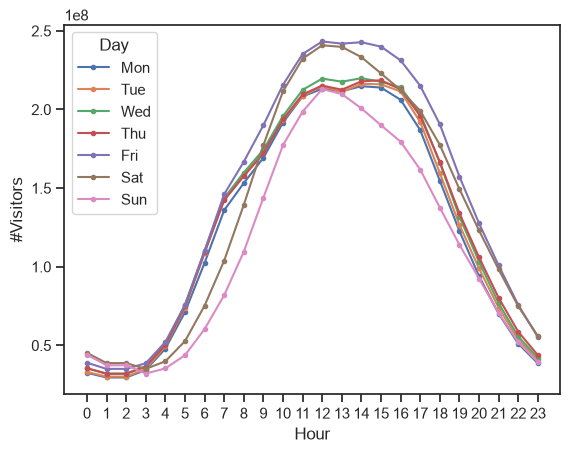

In [19]:
dtype = pl.List(pl.UInt32)
hour_sum = (
    lf.filter(pl.col("VISITS_BY_EACH_HOUR").is_not_null())
    .select(pl.col("VISITS_BY_EACH_HOUR").str.json_decode(dtype).list.to_array(168))
    .collect()
    .to_numpy()
    .sum(axis=0)
)[0]

n = hour_sum.shape[0]
hours_per_day = 24
n_days = n // hours_per_day  # 7

x = np.arange(hours_per_day)
_, ax = plt.subplots()

day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

for i in range(n_days):
    start = i * hours_per_day
    end = start + hours_per_day
    day_data = hour_sum[start:end]
    label = day_names[i] if i < len(day_names) else f"Day {i + 1}"
    ax.plot(x, day_data, label=label, marker="o", markersize=3)

ax.set_xticks(x)
ax.set_xlabel("Hour")
ax.set_ylabel("#Visitors")
ax.legend(title="Day")